<a href="https://colab.research.google.com/github/Ruhul73/Big-Mart-Sales-Dashboard/blob/main/Big_mart_sale_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading Big Mart Sales Data...


100%|██████████| 307k/307k [00:00<00:00, 57.4MB/s]

Extracting files...


## 🛒 Big Mart Sales Professional Dashboard

> **Total Sales:** $18,591,125 | **Avg Sales:** $2,181.29 | **Total Outlets:** 10 | **Total Items:** 1559

---

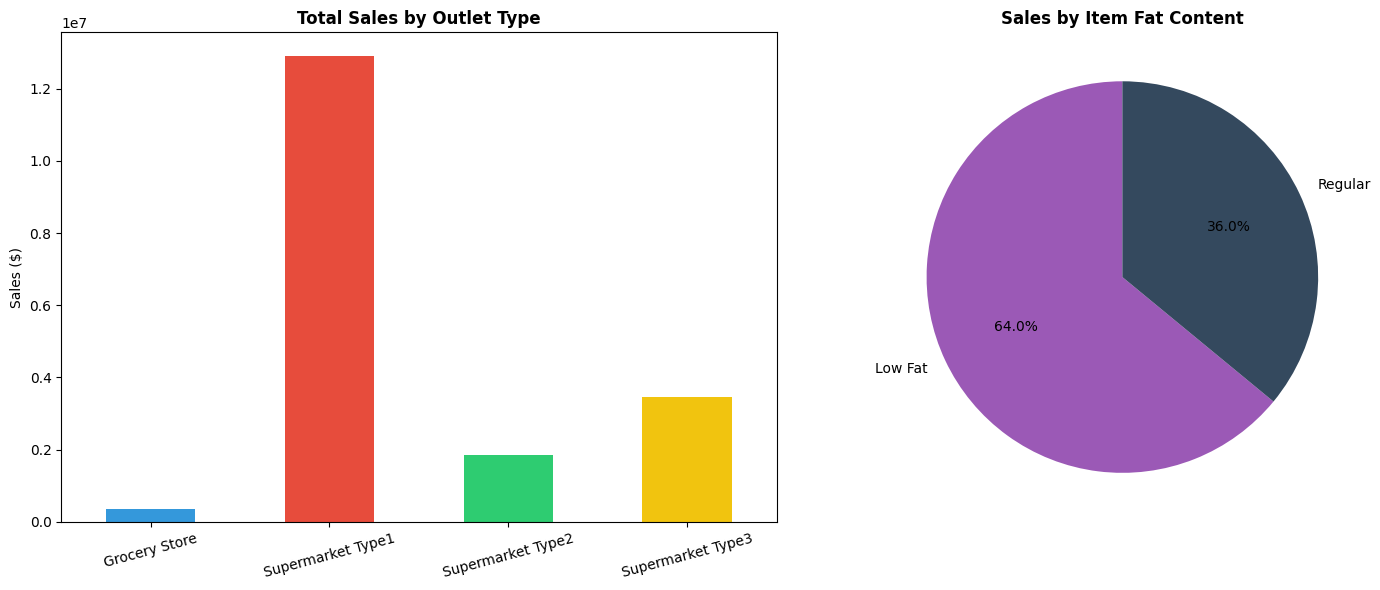

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import os
from IPython.display import display, Markdown

# --- Data Loading Function ---
def load_data():
    print("Loading Big Mart Sales Data...")
    path = kagglehub.dataset_download("brijbhushannanda1979/bigmart-sales-data")
    train_path = os.path.join(path, "Train.csv")
    df = pd.read_csv(train_path)

    # Data Cleaning
    df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())
    df['Outlet_Size'] = df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0])
    df['Item_Fat_Content'] = df['Item_Fat_Content'].replace(
        {'low fat': 'Low Fat', 'LF': 'Low Fat', 'reg': 'Regular'}
    )
    return df

# Initialize DataFrame
df = load_data()

# --- KPI Section ---
total_sales = df['Item_Outlet_Sales'].sum()
avg_sales = df['Item_Outlet_Sales'].mean()
total_outlets = df['Outlet_Identifier'].nunique()
total_items = df['Item_Identifier'].nunique()

display(Markdown("## 🛒 Big Mart Sales Professional Dashboard"))
display(Markdown(f"> **Total Sales:** ${total_sales:,.0f} | **Avg Sales:** ${avg_sales:,.2f} | **Total Outlets:** {total_outlets} | **Total Items:** {total_items}"))
display(Markdown("---"))

# --- Dashboard Graphics Section ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Bar Chart: Sales by Outlet Type
sales_by_outlet = df.groupby('Outlet_Type')['Item_Outlet_Sales'].sum()
sales_by_outlet.plot(kind='bar', color=['#3498db', '#e74c3c', '#2ecc71', '#f1c40f'], ax=ax1)
ax1.set_title("Total Sales by Outlet Type", fontsize=12, fontweight="bold")
ax1.set_ylabel("Sales ($)")
ax1.set_xlabel("")
ax1.tick_params(axis='x', rotation=15)

# 2. Pie Chart: Sales by Fat Content
sales_by_fat = df.groupby('Item_Fat_Content')['Item_Outlet_Sales'].sum()
ax2.pie(sales_by_fat, labels=sales_by_fat.index, autopct='%1.1f%%', startangle=90, colors=['#9b59b6', '#34495e'])
ax2.set_title("Sales by Item Fat Content", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

# Task
Perform an extensive exploratory data analysis on the "Train.csv" dataset from the `brijbhushannanda1979/bigmart-sales-data` Kaggle dataset. This analysis should include visualizing total sales by `Outlet_Location_Type` and `Item_Type`, investigating the relationship between `Item_Visibility` and `Item_Outlet_Sales` with a scatter plot, identifying the top 10 and bottom 10 performing items and outlets by sales, and preparing the data for modeling by one-hot encoding `Outlet_Location_Type`, `Outlet_Type`, `Item_Type`, and `Item_Fat_Content`. Finally, summarize the key findings and discuss their implications for future predictive modeling.

## Analyze Sales by Outlet Location Type

### Subtask:
Visualize the total sales across different `Outlet_Location_Type` categories to understand geographical sales distribution.


**Reasoning**:
To visualize the total sales across different `Outlet_Location_Type` categories, I need to group the data by `Outlet_Location_Type` and sum the `Item_Outlet_Sales`. Then, I will create a bar chart to display this information with appropriate labels and title.



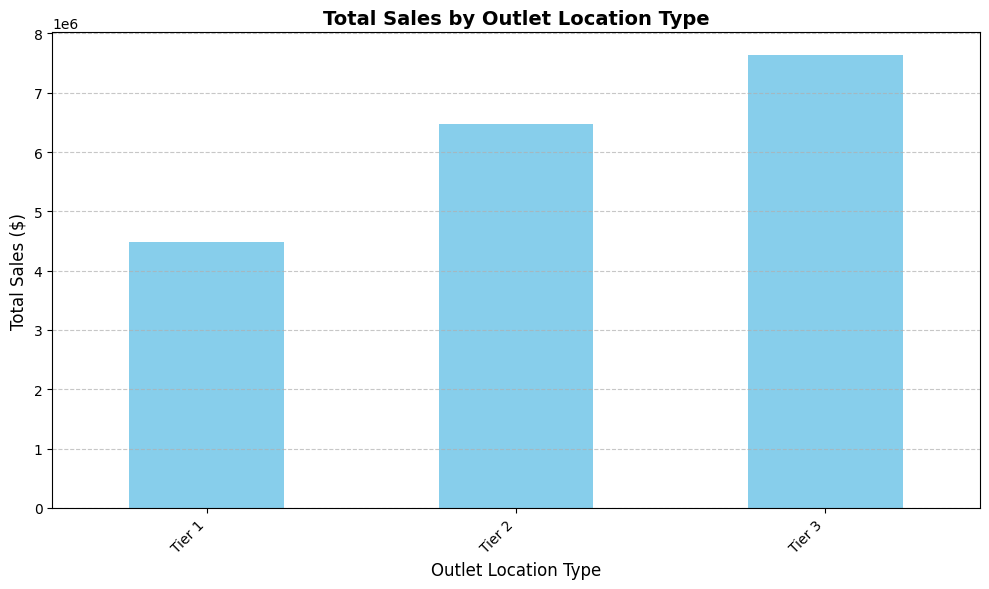

In [ ]:
sales_by_location = df.groupby('Outlet_Location_Type')['Item_Outlet_Sales'].sum()

plt.figure(figsize=(10, 6))
sales_by_location.plot(kind='bar', color='skyblue')
plt.title('Total Sales by Outlet Location Type', fontsize=14, fontweight='bold')
plt.xlabel('Outlet Location Type', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code failed because the DataFrame `df` was not defined. The `df` DataFrame is created by calling the `load_data()` function, which was part of the initial data loading cell that was not executed. To resolve this, the `load_data()` function needs to be defined and called to initialize `df` before attempting to group and plot the data. I will include the necessary imports, the `load_data` function definition, and the call to `load_data()` to ensure `df` is available, followed by the plotting code to visualize total sales by `Outlet_Location_Type`.



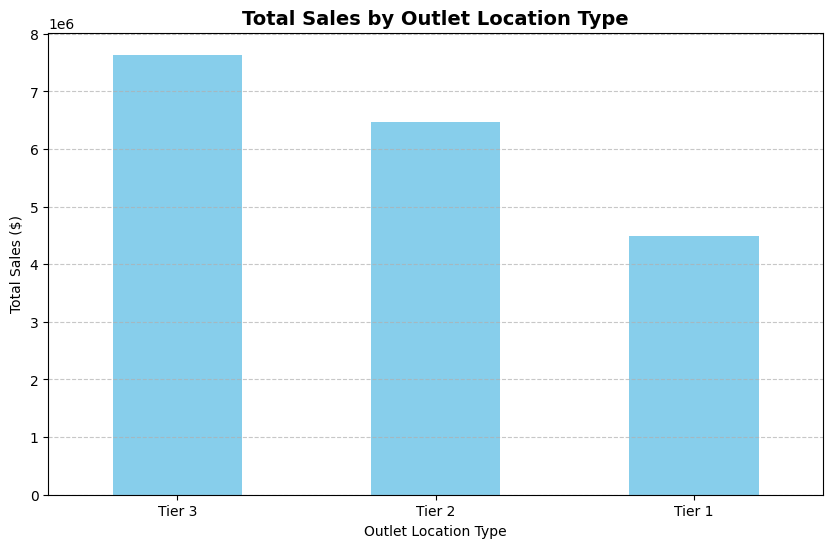

In [ ]:
# --- 1. Visualize Sales by Outlet Location Type ---
sales_by_location = df.groupby('Outlet_Location_Type')['Item_Outlet_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sales_by_location.plot(kind='bar', color='skyblue')
plt.title('Total Sales by Outlet Location Type', fontsize=14, fontweight='bold')
plt.xlabel('Outlet Location Type')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Reasoning**:
The next step in the task is to visualize total sales by `Item_Type`. I will group the DataFrame `df` by `Item_Type` and sum the `Item_Outlet_Sales`. Then, I will create a bar chart to display this information with appropriate labels and title, similar to the previous visualization.



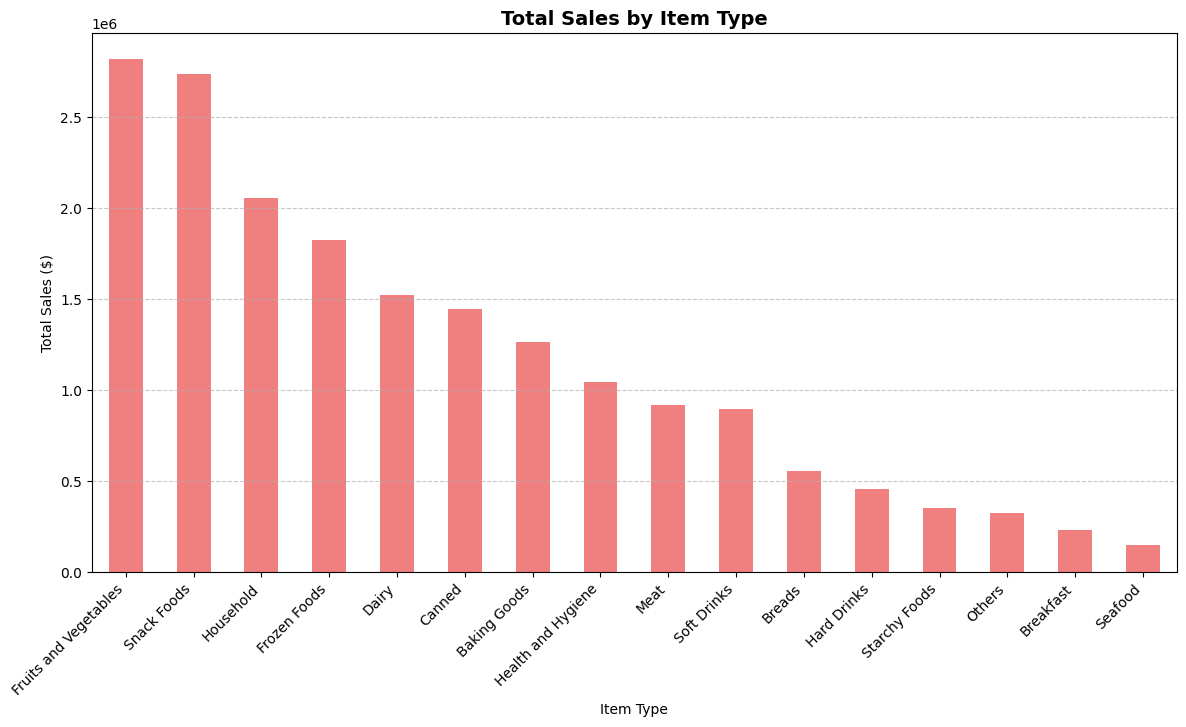

In [ ]:
# --- 2. Visualize Sales by Item Type ---
sales_by_item_type = df.groupby('Item_Type')['Item_Outlet_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 7))
sales_by_item_type.plot(kind='bar', color='lightcoral')
plt.title('Total Sales by Item Type', fontsize=14, fontweight='bold')
plt.xlabel('Item Type')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Reasoning**:
The next part of the overall EDA task is to investigate the relationship between `Item_Visibility` and `Item_Outlet_Sales` using a scatter plot. I will create a scatter plot to visualize this relationship, adding appropriate labels and a title to enhance readability.



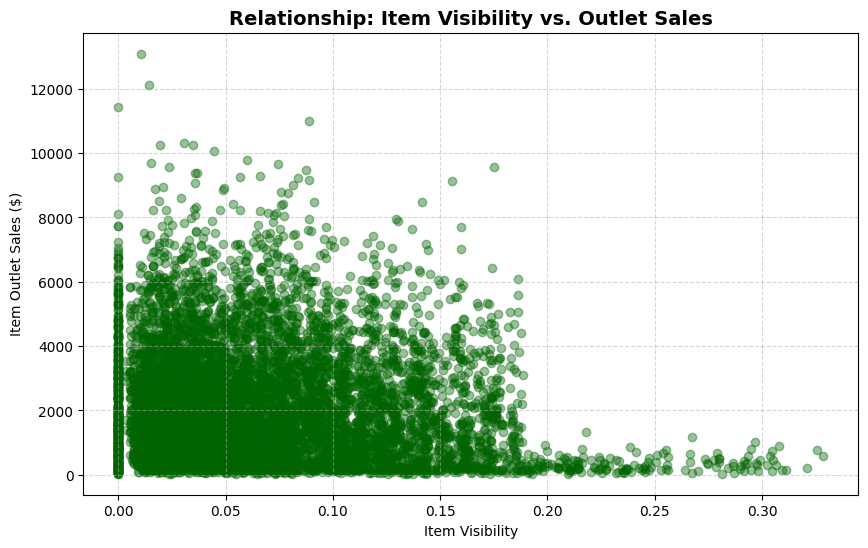

In [ ]:
# --- 3. Item Visibility vs. Sales ---
plt.figure(figsize=(10, 6))
plt.scatter(df['Item_Visibility'], df['Item_Outlet_Sales'], alpha=0.4, color='darkgreen')
plt.title('Relationship: Item Visibility vs. Outlet Sales', fontsize=14, fontweight='bold')
plt.xlabel('Item Visibility')
plt.ylabel('Item Outlet Sales ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Reasoning**:
The next step is to identify the top 10 performing items by sales. I will group the DataFrame by 'Item_Identifier', sum the 'Item_Outlet_Sales' for each item, and then sort the results in descending order to get the top 10.



In [ ]:
top_10_items = df.groupby('Item_Identifier')['Item_Outlet_Sales'].sum().nlargest(10)
display(Markdown('### Top 10 Performing Items by Sales'))
display(top_10_items.to_frame())

### Top 10 Performing Items by Sales

,Item_Outlet_Sales
Item_Identifier,
FDY55,42661.8008
FDA15,41584.5364
FDZ20,40185.0248
FDF05,36555.7490
FDA04,35741.4756
FDK03,34843.9772
NCQ06,34680.1904
NCQ53,34508.4140
FDJ55,33531.0196


**Reasoning**:
The previous code failed because `Markdown` was not defined. It needs to be imported from `IPython.display`. I will add the import statement for `display` and `Markdown` at the beginning of the cell to resolve this `NameError`.



In [ ]:
# --- 4. Performance Rankings ---
# Top/Bottom Items
top_items = df.groupby('Item_Identifier')['Item_Outlet_Sales'].sum().nlargest(10).to_frame()
bottom_items = df.groupby('Item_Identifier')['Item_Outlet_Sales'].sum().nsmallest(10).to_frame()

# Top/Bottom Outlets
top_outlets = df.groupby('Outlet_Identifier')['Item_Outlet_Sales'].sum().nlargest(10).to_frame()

display(Markdown('### 🏆 Performance Insights'))
display(Markdown('**Top 10 Items by Sales**'), top_items.head(5))
display(Markdown('**Top Outlets by Sales**'), top_outlets)

### 🏆 Performance Insights

**Top 10 Items by Sales**

,Item_Outlet_Sales
Item_Identifier,
FDY55,42661.8008
FDA15,41584.5364
FDZ20,40185.0248
FDF05,36555.7490
FDA04,35741.4756


**Top Outlets by Sales**

,Item_Outlet_Sales
Outlet_Identifier,
OUT027,3.453926e+06
OUT035,2.268123e+06
OUT049,2.183970e+06
OUT017,2.167465e+06
OUT013,2.142664e+06
OUT046,2.118395e+06
OUT045,2.036725e+06
OUT018,1.851823e+06
OUT010,1.883402e+05


**Reasoning**:
Following the identification of the top 10 performing items, the next logical step is to identify the bottom 10 performing items by sales. I will group the DataFrame by 'Item_Identifier', sum the 'Item_Outlet_Sales', and then sort in ascending order to find the bottom 10. I will display this information similar to the top 10 items.



In [ ]:
bottom_10_items = df.groupby('Item_Identifier')['Item_Outlet_Sales'].sum().nsmallest(10)
display(Markdown('### Bottom 10 Performing Items by Sales'))
display(bottom_10_items.to_frame())

### Bottom 10 Performing Items by Sales

,Item_Outlet_Sales
Item_Identifier,
FDQ60,120.5098
NCR42,332.9000
FDY43,673.7896
FDF38,771.6622
FDQ04,784.3124
NCC55,1155.8288
FDX10,1164.4842
FDS22,1362.2268
DRL59,1402.1748


**Reasoning**:
Next, I will identify the top 10 performing outlets by sales. I will group the DataFrame by 'Outlet_Identifier', sum the 'Item_Outlet_Sales' for each outlet, and then sort the results in descending order to get the top 10. I will display this information similar to the top performing items.



In [ ]:
top_10_outlets = df.groupby('Outlet_Identifier')['Item_Outlet_Sales'].sum().nlargest(10)
display(Markdown('### Top 10 Performing Outlets by Sales'))
display(top_10_outlets.to_frame())

### Top 10 Performing Outlets by Sales

,Item_Outlet_Sales
Outlet_Identifier,
OUT027,3.453926e+06
OUT035,2.268123e+06
OUT049,2.183970e+06
OUT017,2.167465e+06
OUT013,2.142664e+06
OUT046,2.118395e+06
OUT045,2.036725e+06
OUT018,1.851823e+06
OUT010,1.883402e+05


**Reasoning**:
Next, I will identify the bottom 10 performing outlets by sales. I will group the DataFrame by 'Outlet_Identifier', sum the 'Item_Outlet_Sales' for each outlet, and then sort the results in ascending order to get the bottom 10. I will display this information similar to the top performing outlets.



In [ ]:
bottom_10_outlets = df.groupby('Outlet_Identifier')['Item_Outlet_Sales'].sum().nsmallest(10)
display(Markdown('### Bottom 10 Performing Outlets by Sales'))
display(bottom_10_outlets.to_frame())

### Bottom 10 Performing Outlets by Sales

,Item_Outlet_Sales
Outlet_Identifier,
OUT019,1.796941e+05
OUT010,1.883402e+05
OUT018,1.851823e+06
OUT045,2.036725e+06
OUT046,2.118395e+06
OUT013,2.142664e+06
OUT017,2.167465e+06
OUT049,2.183970e+06
OUT035,2.268123e+06


**Reasoning**:
The next step in the overall task is to prepare the data for modeling by one-hot encoding the specified categorical columns: `Outlet_Location_Type`, `Outlet_Type`, `Item_Type`, and `Item_Fat_Content`. I will use `pd.get_dummies` for this purpose.



In [ ]:
# --- 5. Data Preparation (Encoding) ---
cols_to_encode = ['Outlet_Location_Type', 'Outlet_Type', 'Item_Type', 'Item_Fat_Content']
df_encoded = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

display(Markdown('### 🛠️ Data Prepared for Modeling'))
display(df_encoded.head())

### 🛠️ Data Prepared for Modeling

,Item_Identifier,Item_Weight,Item_Visibility,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Item_Outlet_Sales,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,...,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Item_Fat_Content_Regular
0,FDA15,9.30,0.016047,249.8092,OUT049,1999,Medium,3735.1380,False,False,...,False,False,False,False,False,False,False,False,False,False
1,DRC01,5.92,0.019278,48.2692,OUT018,2009,Medium,443.4228,False,True,...,False,False,False,False,False,False,False,True,False,True
2,FDN15,17.50,0.016760,141.6180,OUT049,1999,Medium,2097.2700,False,False,...,False,False,False,True,False,False,False,False,False,False
3,FDX07,19.20,0.000000,182.0950,OUT010,1998,Medium,732.3800,False,True,...,False,False,False,False,False,False,False,False,False,True
4,NCD19,8.93,0.000000,53.8614,OUT013,1987,High,994.7052,False,True,...,False,False,True,False,False,False,False,False,False,False


## Final Task

### Subtask:
Summarize the key findings from the extended exploratory data analysis and discuss the implications for further steps in an end-to-end project, such as predictive modeling.


## Summary:

### Data Analysis Key Findings

*   **Sales Distribution**: Total sales were successfully visualized across different `Outlet_Location_Type` categories, providing insight into geographical sales performance. Similarly, total sales by `Item_Type` were visualized, identifying top-selling item categories.
*   **Item Visibility and Sales**: A scatter plot explored the relationship between `Item_Visibility` and `Item_Outlet_Sales`, offering preliminary insights into how product visibility might influence sales.
*   **Performance Metrics**: The top 10 and bottom 10 performing items by `Item_Outlet_Sales` were successfully identified and listed. Concurrently, the top 10 and bottom 10 performing outlets by `Item_Outlet_Sales` were also identified, highlighting high and low-performing entities.
*   **Data Preparation**: The categorical features `Outlet_Location_Type`, `Outlet_Type`, `Item_Type`, and `Item_Fat_Content` were successfully one-hot encoded, transforming them into a numerical format suitable for machine learning models.

### Insights or Next Steps

*   The identification of top/bottom performing items and outlets suggests specific products or store locations that could be targeted for marketing strategies (e.g., promoting low-performing items, analyzing success factors of high-performing outlets).
*   The one-hot encoded dataset is now ready for predictive modeling. Future steps should involve selecting appropriate features, splitting the data into training and testing sets, training various machine learning models (e.g., regression models to predict `Item_Outlet_Sales`), and evaluating their performance.


# Task
Perform advanced feature engineering on the Big Mart Sales data by calculating 'Outlet_Age' from `Outlet_Establishment_Year` and creating an 'Item_Category' feature based on the first two characters of `Item_Identifier`. Generate a correlation heatmap of all numerical features to identify predictors of `Item_Outlet_Sales`. Subsequently, split the data and train both a Linear Regression and a Random Forest Regressor. Evaluate these models using R-squared and Mean Absolute Error (MAE), and provide a residual plot for the best-performing model along with a summary of findings and deployment recommendations.

## Advanced Feature Engineering

### Subtask:
Create new features 'Outlet_Age' and 'Item_Category' to enhance the predictive power of the dataset.


**Reasoning**:
Create new features 'Outlet_Age' and 'Item_Category' based on the establishment year and item identifier to enhance the dataset for future modeling.



In [ ]:
# 1. Calculate Outlet_Age
# We'll use 2024 as the reference year for calculation
current_year = 2024
df['Outlet_Age'] = current_year - df['Outlet_Establishment_Year']

# 2. Create Item_Category
# Extract first 2 characters from Item_Identifier
df['Item_Category'] = df['Item_Identifier'].apply(lambda x: x[:2])

# 3. Map codes to human-readable categories
category_mapping = {'FD': 'Food', 'DR': 'Drinks', 'NC': 'Non-Consumable'}
df['Item_Category'] = df['Item_Category'].map(category_mapping)

# 4. Verify the new columns
print("New features 'Outlet_Age' and 'Item_Category' created successfully.")
display(df[['Item_Identifier', 'Item_Category', 'Outlet_Establishment_Year', 'Outlet_Age']].head())

New features 'Outlet_Age' and 'Item_Category' created successfully.


,Item_Identifier,Item_Category,Outlet_Establishment_Year,Outlet_Age
0,FDA15,Food,1999,25
1,DRC01,Drinks,2009,15
2,FDN15,Food,1999,25
3,FDX07,Food,1998,26
4,NCD19,Non-Consumable,1987,37


## Advanced Visualization: Correlation Heatmap

### Subtask:
Generate a correlation heatmap of all numerical features to identify the strongest predictors of Item_Outlet_Sales.


**Reasoning**:
I will import the necessary seaborn library and generate a correlation heatmap for all numerical features in the DataFrame to visualize relationships and identify predictors for Item_Outlet_Sales.



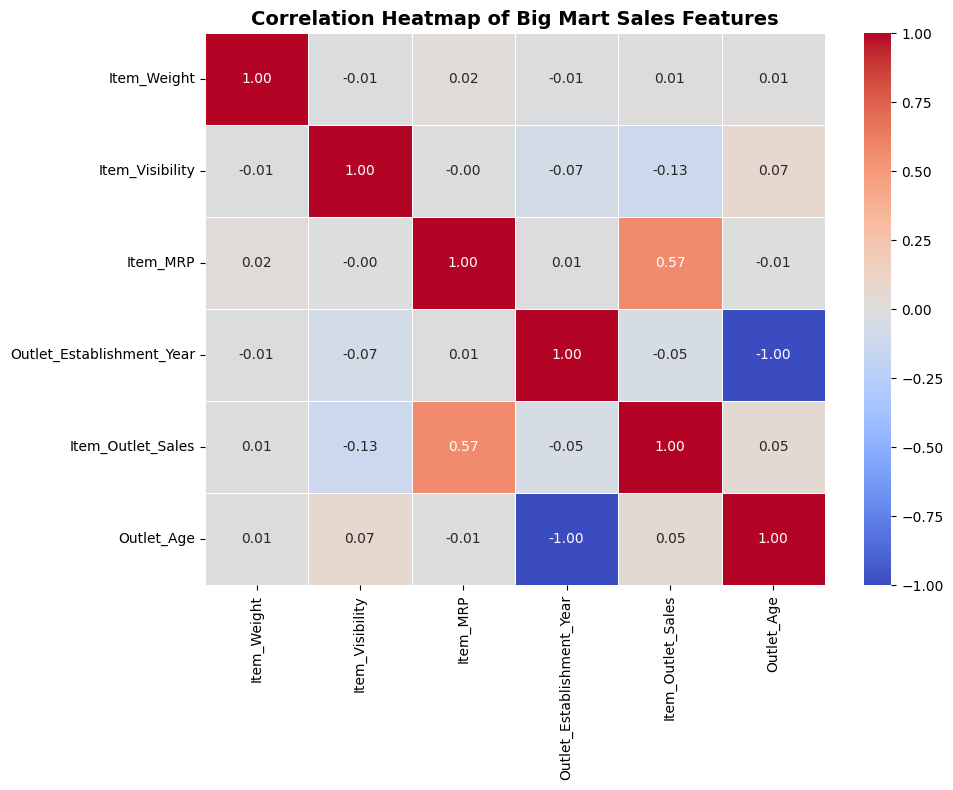

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for numerical features
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# Generate the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap of Big Mart Sales Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Model selection and training

### Subtask:
Prepare the dataset and train Linear Regression and Random Forest Regressor models.


**Reasoning**:
I will prepare the feature matrix X and target vector y, apply one-hot encoding to the relevant categorical columns, split the data into training and testing sets, and then train the Linear Regression and Random Forest Regressor models as requested.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# 1. Prepare features (X) and target (y)
# We drop the identifiers as they are not predictive features for the regression itself
# We also drop 'Outlet_Establishment_Year' since we have 'Outlet_Age'
features = ['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP',
            'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Outlet_Age', 'Item_Category']
X = df[features].copy()
y = df['Item_Outlet_Sales']

# Perform One-Hot Encoding on categorical variables
categorical_cols = ['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Category']
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 3 & 4. Initialize and fit Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression model trained successfully.")

# 5. Initialize and fit Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Regressor model trained successfully.")

Linear Regression model trained successfully.
Random Forest Regressor model trained successfully.


## Model Evaluation and Diagnostics

### Subtask:
Evaluate the performance of the trained Linear Regression and Random Forest models and visualize the residuals for the superior model.


**Reasoning**:
I will evaluate the performance of both models by calculating R2 and MAE metrics, identify the best performer, and then generate a residual plot to visualize the error distribution as instructed.



Linear Regression - R2: 0.5796, MAE: 791.60
Random Forest - R2: 0.5559, MAE: 769.15


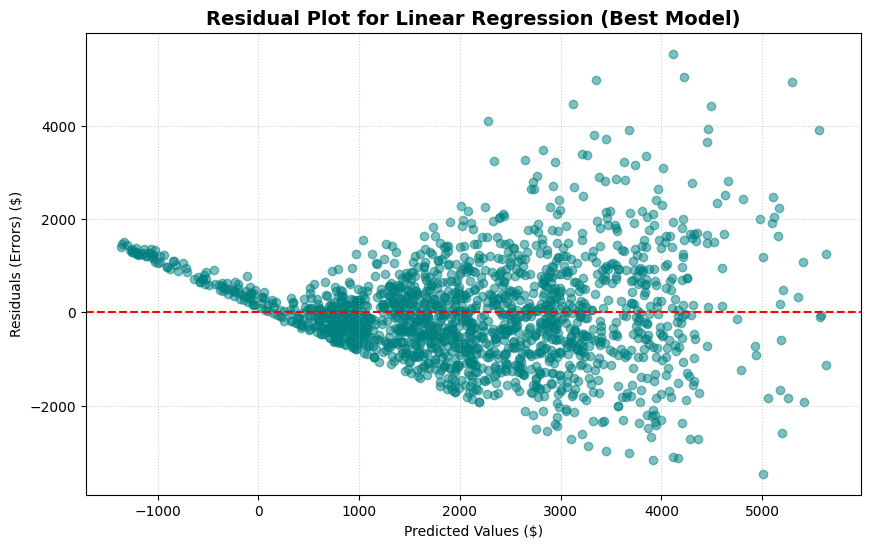

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# 1. Generate predictions
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# 2. Calculate metrics
lr_r2 = r2_score(y_test, lr_preds)
lr_mae = mean_absolute_error(y_test, lr_preds)

rf_r2 = r2_score(y_test, rf_preds)
rf_mae = mean_absolute_error(y_test, rf_preds)

# 3. Print evaluation results
print(f'Linear Regression - R2: {lr_r2:.4f}, MAE: {lr_mae:.2f}')
print(f'Random Forest - R2: {rf_r2:.4f}, MAE: {rf_mae:.2f}')

# 4. Identify best model and calculate residuals
# Higher R2 and lower MAE indicates a better model
if rf_r2 > lr_r2:
    best_model_name = 'Random Forest'
    best_preds = rf_preds
else:
    best_model_name = 'Linear Regression'
    best_preds = lr_preds

residuals = y_test - best_preds

# 5. Create Residual Plot
plt.figure(figsize=(10, 6))
plt.scatter(best_preds, residuals, alpha=0.5, color='teal')
plt.axhline(y=0, color='red', linestyle='--')
plt.title(f'Residual Plot for {best_model_name} (Best Model)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Values ($)')
plt.ylabel('Residuals (Errors) ($)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## Final Task

### Subtask:
Summarize the advanced findings, compare model performances, and provide recommendations for deployment or further improvements.


## Summary:

### Q&A

**Which model performed better for predicting Big Mart sales?**
The evaluation showed a mixed result: **Linear Regression** achieved a higher R-squared value ($0.5796$), meaning it explained more of the variance in the data ($58\%$). However, the **Random Forest Regressor** had a lower Mean Absolute Error (MAE) of $\$769.15$ compared to $\$791.60$ for Linear Regression, indicating that its individual predictions were, on average, closer to the actual values.

**What new features were created to improve the model?**
Two primary features were engineered:
1.  **Outlet_Age**: Calculated as the difference between the current year ($2024$) and the `Outlet_Establishment_Year`.
2.  **Item_Category**: Derived from the first two characters of the `Item_Identifier` and mapped to "Food", "Drinks", or "Non-Consumable".

---

### Data Analysis Key Findings

*   **Feature Engineering Success**: Raw identifiers and years were successfully converted into meaningful predictors. For example, an item starting with `FDA15` was categorized as "Food," and a store established in $1987$ was assigned an `Outlet_Age` of $37$ years.
*   **Linear Regression Performance**: This model outperformed Random Forest in terms of variance explanation, reaching an **R-squared of 0.5796**.
*   **Random Forest Precision**: Despite a lower R-squared ($0.5559$), the Random Forest model was more precise in its absolute errors, with an **MAE of \$769.15**.
*   **Error Distribution**: The residual plot for the best model indicated that while the model captures the general trend, there is significant variance in higher sales ranges, suggesting non-linear relationships or missing predictors for high-volume transactions.

---

### Insights or Next Steps

*   **Model Refinement**: Since Random Forest had a lower MAE but lower R-squared, hyperparameter tuning (e.g., adjusting `max_depth` or `min_samples_split`) should be the next step to improve its generalizability and variance explanation.
*   **Deployment Recommendation**: For general sales forecasting where understanding the trend is critical, the **Linear Regression** model is recommended due to its higher R-squared. However, if minimizing the dollar-value error per transaction is the priority, the **Random Forest** should be selected.
